In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']

sys.path.append(os.path.join(LOCAL_PATH, "src/python"))

from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import mahalanobis
from sklearn.metrics.pairwise import cosine_distances

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11

#os.environ['LOKY_MAX_CPU_COUNT'] = '1' # because of windows core count warning

with open('../../config.local.yaml', 'r') as f:
    local_config = yaml.safe_load(f)
with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

LOCAL_PATH = local_config['LOCAL_PATH']
DATA_PATH = local_config['DATA_PATH']
EMBEDDING_DIMENSION = config['EMBEDDING_DIMENSION']

rng = np.random.default_rng(12898)

PCA_RANDOM_STATE = 37
KMEANS_RANDOM_STATE = 42

N_CLUSTERS = 3
N_COMPONENTS = 10

In [2]:
df = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data.parquet"))
df_emb = pd.read_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "embeddings.parquet"))

In [3]:
embeddings = np.array(df_emb['embedding'].tolist())

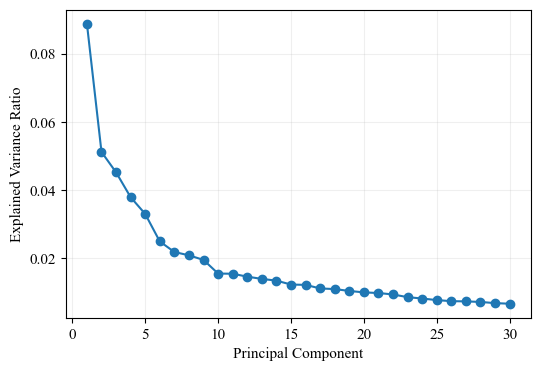

In [4]:
# PCA scree plot

pca = PCA(random_state=PCA_RANDOM_STATE)
pca.fit(embeddings)
explained_variance = pca.explained_variance_ratio_[0:30]
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
#plt.title('Scree Plot of PCA Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(alpha=0.2)
filename = os.path.join(LOCAL_PATH, 'figures', 'fig_scree_plot.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{Scree Plot of PCA Components} \label{fig_scree_plot}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_scree_plot.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note:} Shows how much total variance in the 1,536 dimensional embedding space of the corpus of agenda items is explained by each principal component (up to the first 30).}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_scree_plot.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [5]:
# Reduce embeddings to 10 dimensions
pca = PCA(n_components=N_COMPONENTS, random_state=PCA_RANDOM_STATE)
embeddings_reduced = pca.fit_transform(embeddings)

embeddings_reduced.shape


(818, 10)

In [6]:
# Cluster into 3 clusters using kmeans

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=KMEANS_RANDOM_STATE)
kmeans.fit(embeddings_reduced)

df['cluster'] = kmeans.labels_
df['cluster'].value_counts()

cluster
2    434
1    317
0     67
Name: count, dtype: int64

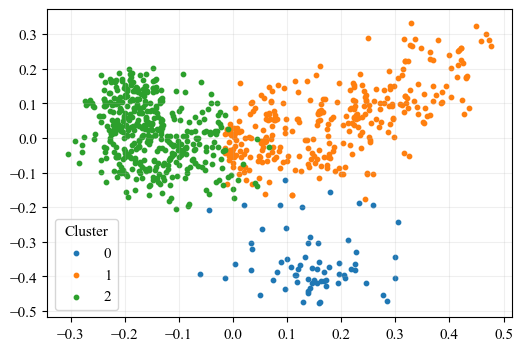

In [7]:
# Scatter plot colored by cluster

plt.figure(figsize=(6, 4))
#colormap = ['blue', 'red', 'green']
for i in range(N_CLUSTERS):
    myx = embeddings_reduced[kmeans.labels_ == i, 0]
    myy = embeddings_reduced[kmeans.labels_ == i, 1]
    #plt.scatter(myx, myy, alpha=0.5, label=f'{i}', color=colormap[i])
    plt.scatter(myx, myy, alpha=1.0, s=10, label=f'{i}')
plt.legend(title='Cluster')
plt.grid(alpha=0.2)
filename = os.path.join(LOCAL_PATH, 'figures', 'fig_clusters.pdf')
plt.savefig(filename, bbox_inches='tight')
plt.show()

tex = r"""
\begin{figure}[H]
\caption{PCA Reduced Embeddings with K-Means Clustering} \label{fig_clusters}
\vspace{-0.5cm}
\begin{center}
\includegraphics[width=\textwidth]{figures/fig_clusters.pdf}
\end{center}
\vspace{-0.4cm}
{\footnotesize \textit{Note}: Result of K-means clustering with three clusters on the first 10 principal components of the embedding space. The first two dimensions of the 10-dimensional subspace are shown. Each dot is an agenda item.}
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "figures", "fig_clusters.tex"), "w", encoding='utf-8') as f:
    f.write(tex)

In [8]:
# Show random examples from each cluster
for cluster in sorted(df['cluster'].unique()):
    print(f"Cluster {cluster}:")
    cluster_items = df[df['cluster'] == cluster]
    sample_items = cluster_items.sample(3)
    for idx, row in sample_items.iterrows():
        print("---")
        print(row['agenda_summary'])
    print("======")
    print("")

Cluster 0:
---
Appeal of the Advisory Agency's approval of Vesting Tentative Tract Map No. 82227-CN for the merger and resubdivision of five lots, including one master ground lot, four airspace lots, and 178 residential condominium units, located at 942 North Broadway Avenue in the Central City North Community Plan area. The project was found exempt from CEQA as a transit priority project under a Sustainable Communities Project CEQA Exemption adopted by City Council on February 20, 2019.
---
Appeal of a Deputy Advisory Agency determination approving a Vesting Tentative Tract Map (VTT-82288) for a 115,674 square-foot site in Venice. The proposed project involves merger and re-subdivision to create two ground lots and seven airspace lots supporting up to 140 dwelling units, 685 sq ft of supportive uses, 2,255 sq ft of retail, an 810 sq ft restaurant, 2,875 sq ft of art studio space, and a new public parking structure. The project was found statutorily exempt from CEQA under AB 1197 as su

In [9]:
# Calculate mahalanobis distance

cov_invs = {}
for cluster in kmeans.labels_:
    idx = df['cluster'] == cluster
    cov = np.cov(embeddings_reduced[idx], rowvar=False) # rowvar=False treats rows as obs and cols as vars (default is other way around)
    cov_invs[cluster] = np.linalg.inv(cov)

df['mahalanobis'] = np.nan
for idx, row in df.iterrows():
    cluster = row['cluster']
    x = embeddings_reduced[idx]
    centroid = kmeans.cluster_centers_[cluster]
    df.at[idx, 'mahalanobis'] = mahalanobis(x, centroid, cov_invs[cluster])


In [10]:
# Calculate euclidian distance

df['euclidean'] = np.nan
for idx, row in df.iterrows():
    cluster = row['cluster']
    x = embeddings_reduced[idx]
    centroid = kmeans.cluster_centers_[cluster]
    df.at[idx, 'euclidean'] = np.linalg.norm(x - centroid)

df['euclidean'] = df['euclidean'] / df['euclidean'].std()  # normalize to std 1

In [11]:
# calculate cosine distance

df['cosine'] = np.nan
for idx, row in df.iterrows():
    x = embeddings_reduced[idx].reshape(1, -1) # reshape to 2d for sklearn function
    centroid = kmeans.cluster_centers_[row['cluster']].reshape(1, -1)
    df.at[idx, 'cosine'] = cosine_distances(x, centroid)[0][0]

df['cosine'] = df['cosine'] / df['cosine'].std()  # normalize to std 1


In [12]:
# Output dataframe 

df.to_parquet(os.path.join(DATA_PATH, "intermediate_data/cpc", "analysis_data_w_distances.parquet"))
